In [1]:
import sys
from pathlib import Path
root_path = Path().resolve().parent
sys.path.insert(0, str(root_path))

from torch.utils.data import DataLoader, Subset
from models.vgg16 import BrainMRI, VGG16, get_train_transforms
import torch

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
root_folder_dir = "../data/brain-tumor-mri-deduplicated/"
split = 'train'

train_transforms = get_train_transforms(do_augment=False)
train_dataset = BrainMRI(root_folder_dir, split, train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

idx_to_classes = {idx: cls for idx, cls in enumerate(train_dataset.classes)}

c:\Users\victo\anaconda3\envs\deepsearch\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


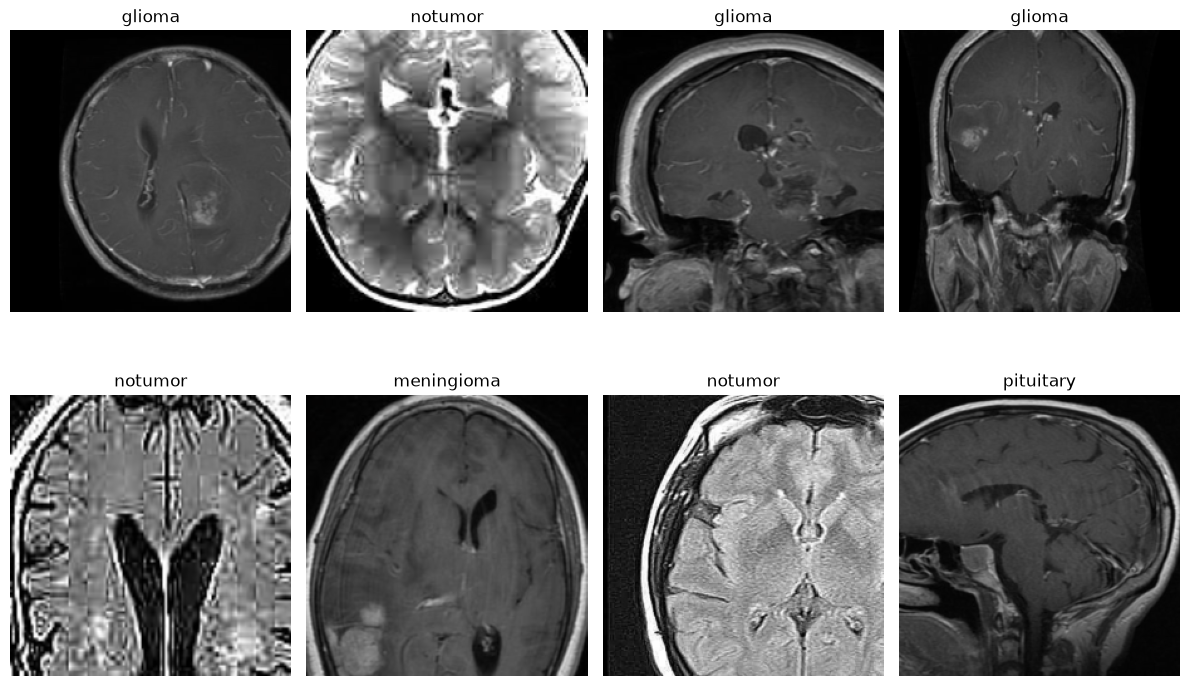

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
indices = torch.randperm(len(train_dataset))
visualize = Subset(train_dataset, indices)

mean = torch.Tensor([0.485, 0.456, 0.406])
std = torch.Tensor([0.229, 0.224, 0.225])
for i, sample in enumerate(visualize):
    if i > 7:
        break
    vis = sample[0].permute(1, 2, 0)
    vis = vis * std.view(1, 1, 3) + mean.view(1, 1, 3)
    vis = torch.clamp(vis, min=0, max=1).numpy()

    row = i // 4
    col = i % 4
    axes[row, col].imshow(vis)
    axes[row, col].set_title(idx_to_classes[sample[1]])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [4]:
model = VGG16(num_classes=4)

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()
num_epochs = 2

for _ in range(num_epochs):
    for i, batch in enumerate(train_dataloader):

        img, label = batch[0], batch[1]
        pred = model(img)
        loss = loss_fn(pred, label)
        optimizer.zero_grad()
        loss.backward()

        if i % 20 == 0:
            print(f"Loss at {i}: {loss}")


Loss at 0: 1.3885505199432373
Loss at 20: 1.380288004875183
Loss at 40: 1.3863251209259033
Loss at 60: 1.3833354711532593
Loss at 80: 1.385956883430481
Loss at 100: 1.3859336376190186
Loss at 120: 1.3859614133834839
Loss at 140: 1.3853232860565186
Loss at 160: 1.3895282745361328


KeyboardInterrupt: 

In [6]:
from torch.utils.tensorboard import SummaryWriter

ModuleNotFoundError: No module named 'tensorboard'

In [11]:
print(f"{torch.__version__}")

2.12.0+cpu


In [10]:
import torch